# 🚀 Introduction: Unlocking the French Market in 2025

Welcome to this Exploratory Data Analysis (EDA) of the CAC 40 index! The goal of this notebook is to dissect the behavior of the French stock market throughout the entire year of 2025. Whether you are a finance enthusiast or a data scout, we will uncover which companies dominated the market, which ones struggled, and how the overall French economy breathed day by day. Let's dive in!

# 📦 Loading the Tools & Libraries

Before we can play with the numbers, we need to set up our laboratory. In this section, we import the core Python data stack: pandas for handling our dataset spreadsheet-style, and the powerful duo matplotlib + seaborn to craft clean, colorful, and insightful financial charts.

In [21]:
# Importing core libraries for data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Setting up the visualization style for beautiful charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

print("Tools and libraries successfully loaded! 🛠️")

Tools and libraries successfully loaded! 🛠️


# 🛠️ Phase 1: Environment Setup & Data Loading

Description: In this first step, we import the essential Python libraries for data analysis and visualization (pandas, matplotlib, seaborn). Then, we load our CAC 40 CSV file to make sure the data is properly read by our script and ready for action.

In [22]:
# Loading the dataset (Make sure the file name matches your Kaggle input)
# If you uploaded the CSV directly to Kaggle, the path will look like '/kaggle/input/.../evolution_cac40_2025.csv'
try:
    df = pd.read_csv("evolution_cac40_2025.csv")
    print("Data successfully loaded! 🚀")
except FileNotFoundError:
    # Fallback for Kaggle environment structure
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for filename in filenames:
            if "cac40" in filename:
                df = pd.read_csv(os.path.join(dirname, filename))
                print(f"Data successfully loaded from Kaggle input: {filename} 🚀")

# Displaying the first 5 rows of the dataset
df.head()

Data successfully loaded from Kaggle input: evolution_cac40_2025.csv 🚀


,date,nom entreprise,valeur début,valeur fin
0,2025-01-02,Accor,45.84,45.86
1,2025-01-03,Accor,45.74,44.75
2,2025-01-06,Accor,44.92,45.32
3,2025-01-07,Accor,45.26,45.24
4,2025-01-08,Accor,45.32,45.43


# 🔍 Phase 2: Data Inspection & Cleaning

Before diving into beautiful charts, we need to understand our dataset's DNA. This phase is dedicated to inspecting column types (making sure prices are numbers and dates are in datetime format), checking the exact number of companies present, and hunting for any missing values.

In [23]:
# 1. Check the global shape of the dataset (Rows, Columns)
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")

# 2. Inspect data types and missing values
print("--- Dataset Information ---")
df.info()

# 3. Check for any missing values explicitly
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# 4. Count unique companies in the dataset
unique_companies = df['nom entreprise'].nunique()
print(f"\n--- Number of unique companies: {unique_companies} ---")

# 5. DATA CLEANING: Convert 'date' column from string to actual datetime format
# This is crucial for chronological plotting later!
df['date'] = pd.to_datetime(df['date'])

print("\nData inspection completed and 'date' column successfully converted! 🧹✨")

Dataset Shape: 9652 rows and 4 columns.

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9652 entries, 0 to 9651
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            9652 non-null   object 
 1   nom entreprise  9652 non-null   object 
 2   valeur début    9652 non-null   float64
 3   valeur fin      9652 non-null   float64
dtypes: float64(2), object(2)
memory usage: 301.8+ KB

--- Missing Values Count ---
date              0
nom entreprise    0
valeur début      0
valeur fin        0
dtype: int64

--- Number of unique companies: 38 ---

Data inspection completed and 'date' column successfully converted! 🧹✨


# 📈 Phase 3: Feature Engineering & Daily Performance

Let's upgrade our dataset! We will enrich the data by creating new useful variables. We will calculate the daily return percentage for each stock (the gap between close and open prices) as well as the raw price variation in Euros for every single trading day of 2025.

In [24]:
# 1. Calculate the daily price change in Euros
df['variation_euros'] = df['valeur fin'] - df['valeur début']

# 2. Calculate the daily return percentage
# Formula: ((Close - Open) / Open) * 100
df['performance_pourcentage'] = ((df['valeur fin'] - df['valeur début']) / df['valeur début']) * 100

# 3. Round the new columns to 2 decimal places for clean formatting
df['variation_euros'] = df['variation_euros'].round(2)
df['performance_pourcentage'] = df['performance_pourcentage'].round(2)

# 4. Let's see the result on a sample of the dataset
print("--- Sample of the enriched dataset ---")
df[['date', 'nom entreprise', 'valeur début', 'valeur fin', 'variation_euros', 'performance_pourcentage']].head()

--- Sample of the enriched dataset ---


,date,nom entreprise,valeur début,valeur fin,variation_euros,performance_pourcentage
0,2025-01-02,Accor,45.84,45.86,0.02,0.04
1,2025-01-03,Accor,45.74,44.75,-0.99,-2.16
2,2025-01-06,Accor,44.92,45.32,0.40,0.89
3,2025-01-07,Accor,45.26,45.24,-0.02,-0.04
4,2025-01-08,Accor,45.32,45.43,0.11,0.24


# 🏆 Phase 4: The 2025 Leaders & Laggards (Top / Flop)

Time for some real insights! In this phase, we isolate the very first and last trading days of the year for each company to calculate their overall 2025 performance. We will then plot the Top 5 winning stocks (the "Leaders") and the Flop 5 losing stocks (the "Laggards") using clean bar charts.

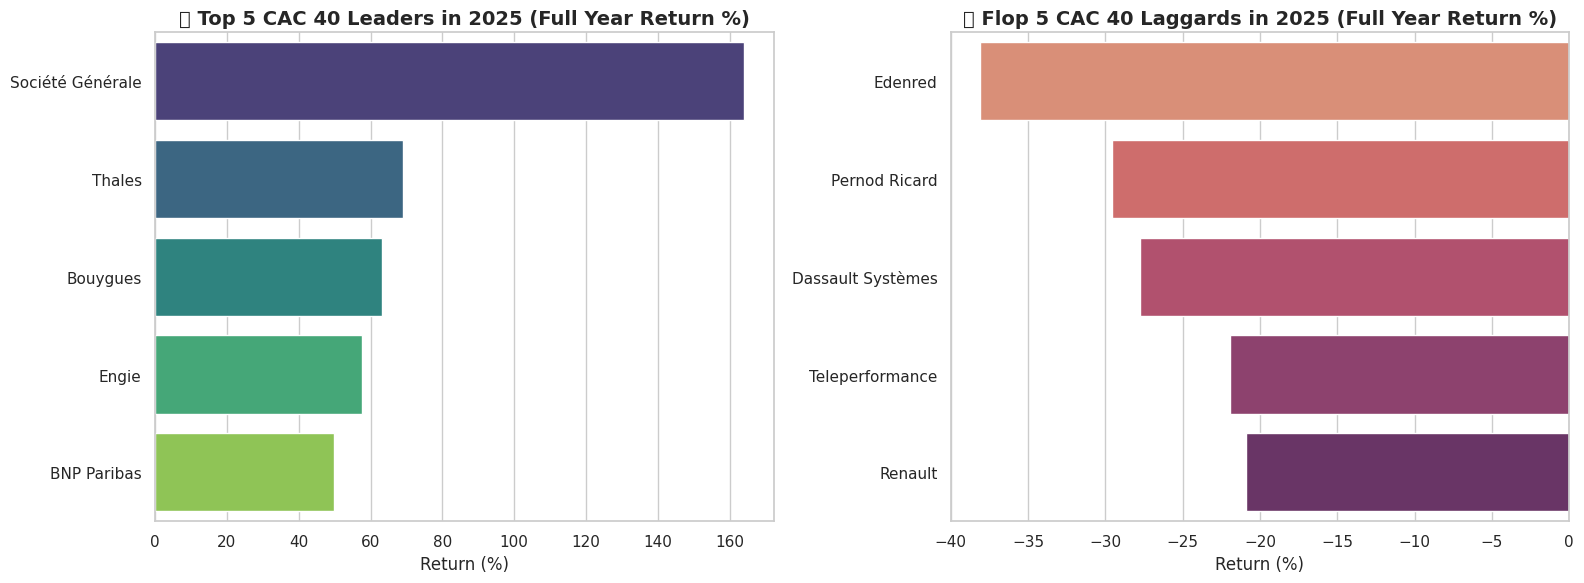

In [25]:
# 1. Calculate the overall 2025 performance for each company
company_returns = []

for company in df['nom entreprise'].unique():
    # Filter data for this specific company and sort by date
    comp_df = df[df['nom entreprise'] == company].sort_values('date')
    
    if len(comp_df) >= 2:
        # Get the first opening price of the year
        initial_price = comp_df.iloc[0]['valeur début']
        # Get the last closing price of the year
        final_price = comp_df.iloc[-1]['valeur fin']
        
        # Calculate full-year return percentage
        full_year_return = ((final_price - initial_price) / initial_price) * 100
        
        company_returns.append({
            'nom entreprise': company,
            'initial_price': initial_price,
            'final_price': final_price,
            'return_pct': round(full_year_return, 2)
        })

# Convert to a DataFrame for easy sorting
df_returns = pd.DataFrame(company_returns)

# 2. Extract the Top 5 and Flop 5
top_5 = df_returns.sort_values('return_pct', ascending=False).head(5)
flop_5 = df_returns.sort_values('return_pct', ascending=True).head(5)

# 3. Plotting the results using Seaborn & Matplotlib
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Chart: Top 5 Leaders (Green)
sns.barplot(
    data=top_5, 
    x='return_pct', 
    y='nom entreprise', 
    ax=axes[0], 
    palette='viridis'
)
axes[0].set_title('🚀 Top 5 CAC 40 Leaders in 2025 (Full Year Return %)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Return (%)', fontsize=12)
axes[0].set_ylabel('', fontsize=12)

# Right Chart: Flop 5 Laggards (Red)
sns.barplot(
    data=flop_5, 
    x='return_pct', 
    y='nom entreprise', 
    ax=axes[1], 
    palette='flare'
)
axes[1].set_title('📉 Flop 5 CAC 40 Laggards in 2025 (Full Year Return %)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Return (%)', fontsize=12)
axes[1].set_ylabel('', fontsize=12)

plt.tight_layout()
plt.show()

# 📊 Phase 5: Visualizing the CAC 40 Global Trend

Here, we aim to capture the big picture of the French market in 2025. By grouping the data by date, we will compute a daily average of all stock prices. This will allow us to plot a beautiful time-series line chart to identify the main market trends, peaks, and drops of the year.

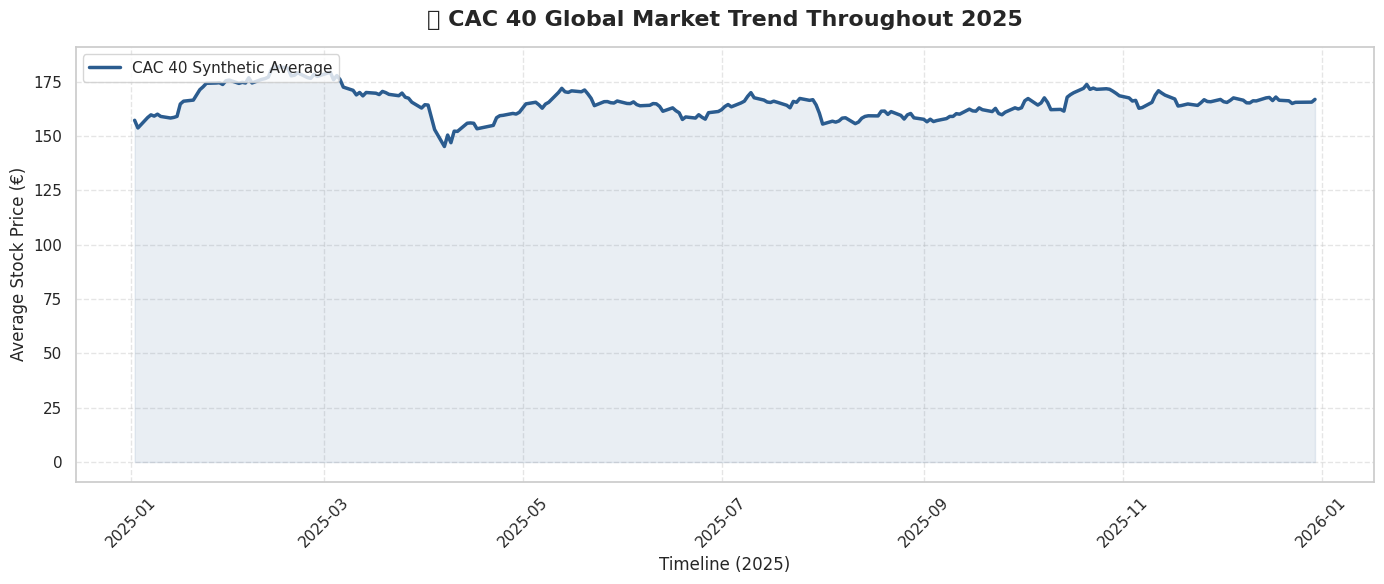

In [26]:
# 1. Group by date to calculate the daily average of 'valeur fin'
# This creates a synthetic index representing the overall market trend
market_trend = df.groupby('date')['valeur fin'].mean().reset_index()

# 2. Plotting the Time-Series Chart
plt.figure(figsize=(14, 6))

# Plot the main line
plt.plot(
    market_trend['date'], 
    market_trend['valeur fin'], 
    color='#2b5c8f', 
    linewidth=2.5, 
    label='CAC 40 Synthetic Average'
)

# Adding shadow under the curve for a premium look
plt.fill_between(
    market_trend['date'], 
    market_trend['valeur fin'], 
    color='#2b5c8f', 
    alpha=0.1
)

# 3. Customizing the chart labels and style
plt.title('📈 CAC 40 Global Market Trend Throughout 2025', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Timeline (2025)', fontsize=12)
plt.ylabel('Average Stock Price (€)', fontsize=12)

# Make the date labels look neat on the X axis
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

# 🎯 Phase 6: Deep Dive into Key Sectors & Conclusion

Let's finish with a bang! We will select a few iconic giants of the index (like the luxury sector with LVMH or aerospace with Airbus) to overlay their curves and compare their trajectories. The notebook will wrap up with a summary of the key takeaways from the French economy in 2025.

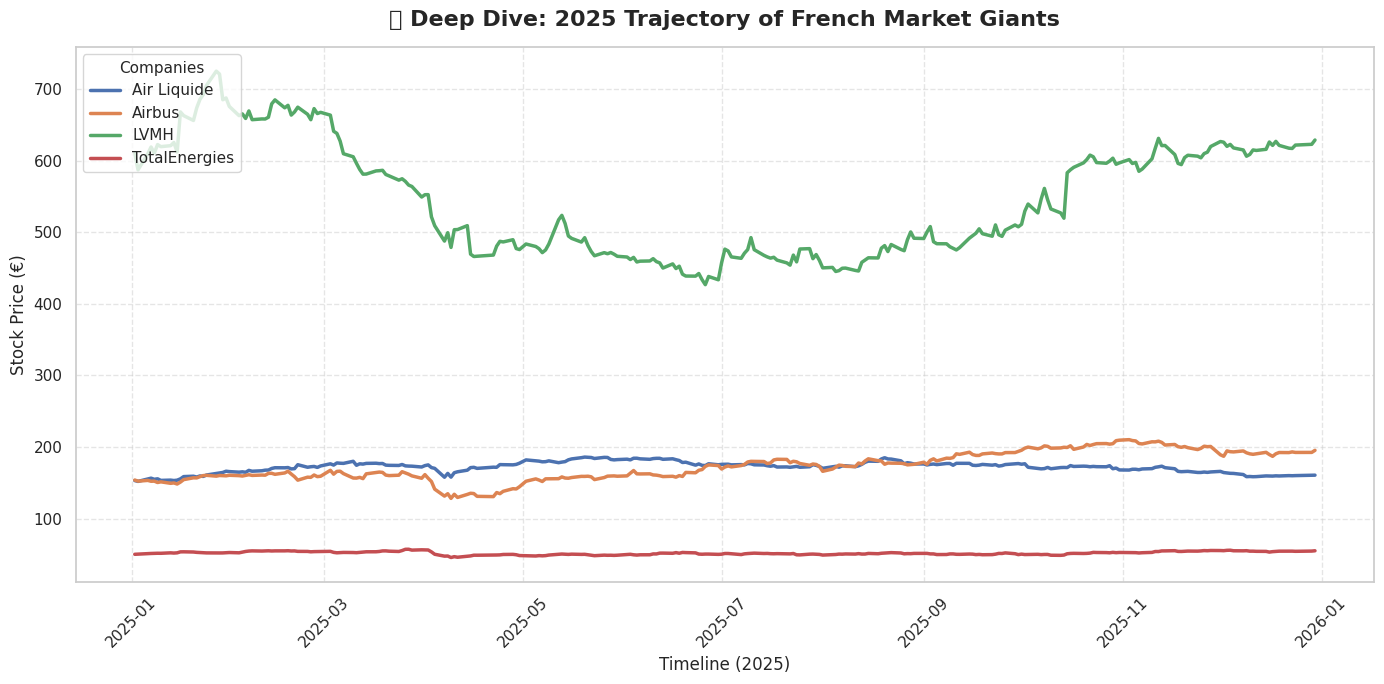

In [27]:
# 1. Selection of iconic companies representing different sectors
# Note: Ensure these names exactly match the spelling in your dataset's 'nom entreprise' column
selected_giants = ["LVMH", "Airbus", "TotalEnergies", "Air Liquide"]

# Filter the main dataset to keep only our selected giants
df_giants = df[df['nom entreprise'].isin(selected_giants)].copy()

# 2. Plotting the comparative chart
plt.figure(figsize=(14, 7))

# Create a line plot with a different color per company
sns.lineplot(
    data=df_giants, 
    x='date', 
    y='valeur fin', 
    hue='nom entreprise', 
    linewidth=2.5
)

# 3. Customizing the chart
plt.title('🎯 Deep Dive: 2025 Trajectory of French Market Giants', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Timeline (2025)', fontsize=12)
plt.ylabel('Stock Price (€)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Companies', title_fontsize='11', loc='upper left')

plt.tight_layout()
plt.show()